# Clean up extracted conversations

In [19]:
input_dir = '../output/dialogues/pkna-*.json'
output_merged = '../output/dataset/dialogues-merged.json'
output_review = '../input/review/input.json'
max_attribution_confidence = 5
min_line_confidence = 0.5

recompute_merge = False

In [2]:
import glob

input_files = glob.glob(input_dir)
input_files.sort()

input_files[:10], len(input_files)

(['../output/dialogues/pkna-0-2-conv-005-0.json',
  '../output/dialogues/pkna-0-2-conv-005-1.json',
  '../output/dialogues/pkna-0-2-conv-005-2.json',
  '../output/dialogues/pkna-0-2-conv-005-3.json',
  '../output/dialogues/pkna-0-2-conv-011-0.json',
  '../output/dialogues/pkna-0-2-conv-011-1.json',
  '../output/dialogues/pkna-0-2-conv-011-2.json',
  '../output/dialogues/pkna-0-2-conv-011-3.json',
  '../output/dialogues/pkna-0-2-conv-011-4.json',
  '../output/dialogues/pkna-0-2-conv-011-5.json'],
 1046)

Sort better, by pkna num, conv num and page

In [3]:
# Better sort the files by pkna, conv, and page
import re

def input_sort_key(filename: str) -> tuple[float, int, int]:
    m = re.search(r'pkna-(.+)-conv-(.+)-(\d)+\.json', filename)
    if not m:
        raise ValueError(f"Filename {filename} does not match expected pattern.")
    pkna = float(m.group(1).replace('-', '.'))
    conv = int(m.group(2))
    page = int(m.group(3))
    return (pkna, conv, page)

input_files.sort(key=input_sort_key)
input_files[:10]

['../output/dialogues/pkna-0-conv-029-0.json',
 '../output/dialogues/pkna-0-conv-029-1.json',
 '../output/dialogues/pkna-0-conv-029-2.json',
 '../output/dialogues/pkna-0-conv-029-3.json',
 '../output/dialogues/pkna-0-conv-029-4.json',
 '../output/dialogues/pkna-0-conv-029-5.json',
 '../output/dialogues/pkna-0-conv-029-6.json',
 '../output/dialogues/pkna-0-conv-029-7.json',
 '../output/dialogues/pkna-0-conv-040-0.json',
 '../output/dialogues/pkna-0-conv-040-1.json']

In [4]:
import json
from dataclasses import dataclass


@dataclass
class Bubble:
    character: str
    text: str
    confidence: int

    def to_dict(self) -> dict:
        return {
            'character': self.character,
            'text': self.text,
            'confidence': self.confidence
        }


@dataclass
class Take:
    dialogue: list[Bubble]


@dataclass
class Page:
    input_page: str
    model: str
    prompt_version: str
    source: str
    takes: list[Take]

    @property
    def page_num(self) -> int:
        _, conv, offset = input_sort_key(self.source)
        return conv + offset

    @property
    def conv_num(self) -> int:
        _, conv, _ = input_sort_key(self.source)
        return conv

    @property
    def pkna(self) -> str:
        m = re.search(r'pkna-(.+)-conv-(.+)-(\d)+\.json', self.source)
        if not m:
            raise ValueError(
                f"Filename {self.source} does not match expected pattern")
        return f"PKNA #{m.group(1).replace('.', '/')}"

    def to_dict(self) -> dict:
        return {
            'input_page': self.input_page,
            'model': self.model,
            'prompt_version': self.prompt_version,
            'source': self.source,
            'pkna': self.pkna,
            'page_num': self.page_num,
            'conv_num': self.conv_num,
            'takes': [
                {
                    'dialogue': [b.to_dict() for b in t.dialogue]
                }
                for t in self.takes
            ]
        }


def read_json_file(filename: str) -> dict:
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)


def dict_to_page(filename: str, d: dict) -> Page:
    return Page(
        input_page=d['page'],
        model=d['model'],
        prompt_version=d['prompt_version'],
        source=filename,
        takes=[
            Take(dialogue=[
                Bubble(
                    character=b['character'],
                    text=b['text'],
                    confidence=b['probability'] / max_attribution_confidence
                )
                for b in t['dialogue']
            ])
            for t in d['takes']
        ]
    )


input_contents = [
    dict_to_page(filename, read_json_file(filename))
    for filename in input_files
]

input_contents[1].to_dict()

{'input_page': '../input/pkna/pkna-0/pkna-0-030.jpg',
 'model': 'gemini-2.5-flash-preview-04-17',
 'prompt_version': '2035c1e1',
 'source': '../output/dialogues/pkna-0-conv-029-1.json',
 'pkna': 'PKNA #0',
 'page_num': 30,
 'conv_num': 29,
 'takes': [{'dialogue': [{'character': 'Paperinik',
     'text': 'Immagino che ti aspetti spiegazioni! Mettiti comodo!',
     'confidence': 1.0},
    {'character': 'Uno', 'text': 'Molto gentile!', 'confidence': 1.0},
    {'character': 'Paperinik',
     'text': 'Dunque sei un computer?',
     'confidence': 1.0},
    {'character': 'Uno',
     'text': "Un'intelligenza artificiale, prego!",
     'confidence': 1.0},
    {'character': 'Uno',
     'text': "Per essere precisi, sono la piu' potente, versatile e sbalorditiva elligenza artificiale mai esistita su questo pianeta!",
     'confidence': 1.0},
    {'character': 'Uno',
     'text': 'Everett Ducklair mi ha programmato per avere qualcuno al suo livello intellettuale con cui parlare!',
     'confidence'

In [5]:
# Normalize character names
import re
import copy
from collections import Counter

char_clusters = {
    'paperinik': ['.*paperinik.*', 'pk', '.*donald duck.*'],
}
char_clusters = {
    k: [re.compile(f"^{v}$") for v in vs]
    for k, vs in char_clusters.items()
}

def normalize_characters(page: Page) -> Page:
    page = copy.deepcopy(page)
    for take in page.takes:
        for bubble in take.dialogue:
            c = bubble.character.strip().lower()
            for k, vs in char_clusters.items():
                if any(re.match(pattern, c) for pattern in vs):
                    c = k
                    break
            bubble.character = c
    return page

norm_characters = [
    normalize_characters(page)
    for page in input_contents
]

character_counts = Counter(
    bubble.character
    for page in norm_characters
    for take in page.takes
    for bubble in take.dialogue
)

character_counts.most_common(10)

[('paperinik', 15065),
 ('uno', 8263),
 ('everett ducklair', 3565),
 ('lyla lay', 229),
 ('woman with red hair', 95),
 ('green creature', 89),
 ('green alien', 81),
 ('angus fangus', 80),
 ('lyla', 66),
 ('purple creature', 63)]

Filter out pages that do not contain Uno at all

In [6]:
def contains_character(page: Page, character: str) -> bool:
    for take in page.takes:
        for bubble in take.dialogue:
            if bubble.character == character:
                return True
    return False

norm_uno_pages = [
    page
    for page in norm_characters
    if contains_character(page, 'uno')
]

# double-check how many pages we filtered out.
filtered_out = [
    page
    for page in norm_characters
    if not contains_character(page, 'uno')
]
len(filtered_out), filtered_out[0].takes[0].dialogue

(198,
 [Bubble(character='purple duck', text='Noi assorbiamo e utilizziamo le energie emotive e cerebrali delle forme di vita intelligente! Per questo abbiamo prelevato...', confidence=0.6),
  Bubble(character='purple duck', text="...a titolo sperimentale il vostro collega van beck! Speravamo che i protagonisti di 'patemi' catalizzassero le emozioni degli spettatori!", confidence=0.6),
  Bubble(character='paperinik', text='Senti, senti...', confidence=1.0),
  Bubble(character='tall purple character', text='Invece siete risultati scarsini. Ma non importa!', confidence=0.6),
  Bubble(character='purple duck', text='Prosciugandovi in massa, al party del caro sam, otterremo ugualmente una buona provvista energetica!', confidence=0.6),
  Bubble(character='character in pink cape', text="E' allucinante! Fa' qualcosa, sam!", confidence=0.6),
  Bubble(character='white fluffy character', text='Inutile, il vostro amico è già stato parzialmente assorbito!', confidence=0.6),
  Bubble(character='smal

Compute the best dialogue (TODO)

In [7]:
from difflib import SequenceMatcher
from dataclasses import dataclass
import numpy as np
from tqdm import tqdm


@dataclass
class DialogueLine:
    character: str
    text: str
    match_confidence: float
    # List of alternatives to this line
    alternatives: list[Bubble]

    @property
    def confidence(self) -> float:
        ans_conf = float(np.mean([b.confidence for b in self.alternatives]))
        return .6 * self.match_confidence + .4 * ans_conf

    @property
    def uno_confidence(self) -> float:
        uno_bubbles = sum(1 for b in self.alternatives if b.character == 'uno')
        return uno_bubbles / len(self.alternatives) if self.alternatives else 0.0

    def to_dict(self) -> dict:
        return {
            'character': self.character,
            'text': self.text,
            'confidence': self.confidence,
            'match_confidence': self.match_confidence,
            'uno_confidence': self.uno_confidence,
            'alternatives': [
                {
                    'character': b.character,
                    'text': b.text,
                    'confidence': b.confidence
                }
                for b in self.alternatives
            ]
        }

@dataclass
class DialoguePage:
    input_page: str
    pkna: str
    page_num: int
    conv_num: int
    dialogue: list[DialogueLine]

    def to_dict(self) -> dict:
        return {
            'input_page': self.input_page,
            'pkna': self.pkna,
            'page_num': self.page_num,
            'conv_num': self.conv_num,
            'dialogue': [d.to_dict() for d in self.dialogue]
        }

    @staticmethod
    def from_dict(d: dict) -> "DialoguePage":
        return DialoguePage(
            input_page=d['input_page'],
            pkna=d['pkna'],
            page_num=d['page_num'],
            conv_num=d['conv_num'],
            dialogue=[
                DialogueLine(
                    character=dl['character'],
                    text=dl['text'],
                    match_confidence=dl['match_confidence'],
                    alternatives=[
                        Bubble(
                            character=b['character'],
                            text=b['text'],
                            confidence=b['confidence']
                        )
                        for b in dl['alternatives']
                    ]
                )
                for dl in d['dialogue']
            ]
        )


def text_similarity(a: str, b: str) -> float:
    """Calculate similarity between two strings"""
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


def find_best_matches(takes: list[Take], threshold: float = 0.8) -> list[DialogueLine]:
    all_dialogues: list[DialogueLine] = []

    # First, align similar bubbles across takes
    for take in takes:
        for bubble in take.dialogue:
            matched = False
            # Try to match with existing dialogues
            for dialogue in all_dialogues:
                if text_similarity(bubble.text, dialogue.alternatives[0].text) > threshold:
                    dialogue.alternatives.append(bubble)
                    matched = True
                    break

            if not matched:
                # Create new dialogue group
                all_dialogues.append(DialogueLine(
                    character=bubble.character,
                    text=bubble.text,
                    match_confidence=1.0,
                    alternatives=[bubble]
                ))

    # Calculate most likely character and text for each dialogue
    result = []
    for dialogue in all_dialogues:
        # Count character occurrences
        char_counts: dict[str, int] = {}
        for bubble in dialogue.alternatives:
            char_counts[bubble.character] = char_counts.get(
                bubble.character, 0) + 1

        # Find most common character
        most_common_char = max(char_counts.items(), key=lambda x: x[1])

        # Find most representative text (highest average similarity)
        text_scores: dict[str, float] = {}
        for bubble1 in dialogue.alternatives:
            score = 0
            for bubble2 in dialogue.alternatives:
                score += text_similarity(bubble1.text, bubble2.text)
            text_scores[bubble1.text] = score / len(dialogue.alternatives)

        best_text = max(text_scores.items(), key=lambda x: x[1])[0]

        result.append(DialogueLine(
            character=most_common_char[0],
            text=best_text,
            match_confidence=most_common_char[1] / len(takes),
            alternatives=dialogue.alternatives
        ))

    # Sort by position in original sequences
    def get_avg_position(dialogue: DialogueLine) -> float:
        positions = []
        for take in takes:
            for i, bubble in enumerate(take.dialogue):
                if any(text_similarity(bubble.text, alt.text) > threshold
                       for alt in dialogue.alternatives):
                    positions.append(i)
        return float(np.mean(positions)) if positions else float('inf')

    result.sort(key=get_avg_position)

    return result

In [8]:
import os
import json

def compute_merge() -> list[DialoguePage]:
    merged_runs = [
        DialoguePage(
            input_page=page.input_page,
            pkna=page.pkna,
            page_num=page.page_num,
            conv_num=page.conv_num,
            dialogue=find_best_matches(page.takes)
        )
        for page in tqdm(norm_uno_pages)
    ]
    # Save the merged runs to a file
    os.makedirs(os.path.dirname(output_merged), exist_ok=True)
    with open(output_merged, 'w', encoding='utf-8') as f:
        json.dump([page.to_dict() for page in merged_runs], f, ensure_ascii=False, indent=4)
    return merged_runs

def load_merge() -> list[DialoguePage]:
    with open(output_merged, 'r', encoding='utf-8') as f:
        merged_runs = json.load(f)
    return [DialoguePage.from_dict(page) for page in merged_runs]

# Load or compute the merged runs
merged_runs = compute_merge() if recompute_merge else load_merge()

In [9]:
for line in merged_runs[0].dialogue:
    print(f"{line.character} ({line.confidence:.2f}) [uno? {line.uno_confidence:.2f}]: {line.text}")

paperinik (0.98) [uno? 0.00]: Hai paura di affrontarmi? Fatti vedere!
paperinik (1.00) [uno? 0.00]: Veramente, mi stai già guardando!
paperinik (0.59) [uno? 0.40]: Io sono questo edificio!
paperinik (0.59) [uno? 0.40]: Ma se proprio hai bisogno di un volto a cui rivolgerti... ecco!
paperinik (1.00) [uno? 0.00]: Glom! Penso di averne viste abbastanza, per una sola notte!
paperinik (1.00) [uno? 0.00]: Facciamoci coraggio!
paperinik (1.00) [uno? 0.00]: Non so cosa tu sia, ma hai di fronte Paperinik!
uno (1.00) [uno? 1.00]: Piacere! Io sono Uno!
paperinik (0.98) [uno? 0.00]: Uno, eh? Dove hai lasciato gli altri?
paperinik (1.00) [uno? 0.00]: Groan! Che battutaccia! È terribile!


## Filter out pages without Uno

In [10]:
pages = [
    page
    for page in merged_runs
    if (
        any(line.character == 'uno' for line in page.dialogue) or
        any(line.uno_confidence > 0.2 for line in page.dialogue)
    )
]

print(f"{len(pages)}/{len(merged_runs)} pages with 'uno' with some confidence")

771/848 pages with 'uno' with some confidence


## Identify low confidence pages

In [27]:
imperfect_pages = [
    page
    for page in merged_runs
    if any(line.confidence < min_line_confidence for line in page.dialogue)
]
print(f"{len(imperfect_pages)}/{len(merged_runs)} pages have some low confidence lines.")

419/848 pages have some low confidence lines.


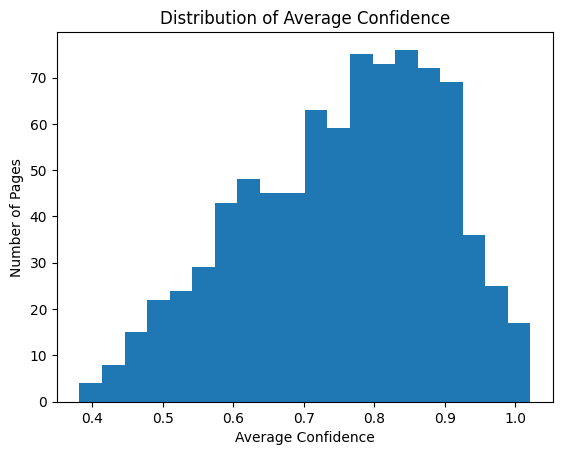

In [22]:
# Distribution of average confidence
import matplotlib.pyplot as plt
import numpy as np

avg_confidences = [
    np.mean([line.confidence for line in page.dialogue])
    for page in merged_runs
]
plt.hist(avg_confidences, bins=20)
plt.xlabel("Average Confidence")
plt.ylabel("Number of Pages")
plt.title("Distribution of Average Confidence")
plt.show()

In [34]:
low_conf_pages = [
    page
    for page in merged_runs
    if np.mean([line.confidence for line in page.dialogue]) <= min_line_confidence
]

# Sample of low confidence page
len(low_conf_pages), low_conf_pages[0].to_dict()

(41,
 {'input_page': '../input/pkna/pkna-0-3/PK.Vol.0-3 002.jpg',
  'pkna': 'PKNA #0-3',
  'page_num': 2,
  'conv_num': 2,
  'dialogue': [{'character': 'green/orange alien creature',
    'text': '...e di pericoloso!',
    'confidence': 0.44000000000000006,
    'match_confidence': 0.2,
    'uno_confidence': 0.0,
    'alternatives': [{'character': 'green/orange alien creature',
      'text': '...e di pericoloso!',
      'confidence': 0.8},
     {'character': 'coolflame (in sphere)',
      'text': '...e di pericoloso!',
      'confidence': 0.8},
     {'character': 'small green creature',
      'text': '... E di pericoloso!',
      'confidence': 0.8},
     {'character': 'alien creature',
      'text': '...e di pericoloso!',
      'confidence': 0.8},
     {'character': 'coolflame creature',
      'text': '...e di pericoloso!',
      'confidence': 0.8}]},
   {'character': 'uno',
    'text': 'Che cosa fate qui, voi Coolflames?',
    'confidence': 0.5760000000000001,
    'match_confidence': 0.

## Prepare review dataset

In [38]:
import json
import os

def drop_alt(p: dict) -> dict:
    """Drop all alternatives from the page"""
    p = copy.deepcopy(p)
    for line in p['dialogue']:
        line['alternatives'] = []
    return p


# The review file is an array of image and ocr text pairs
review_data = [
    {
        'image': page.input_page,
        'ocr': drop_alt(page.to_dict()),
    }
    for page in low_conf_pages
    #if max(line.uno_confidence for line in page.dialogue) > 0.1
]

os.makedirs(os.path.dirname(output_review), exist_ok=True)
with open(output_review, "w", encoding="utf-8") as f:
    json.dump(review_data, f, ensure_ascii=False, indent=2)

## Dataset (TODO)

In [14]:
# Split by pkna and conversation
import pandas as pd

df = pd.DataFrame.from_records([
    {
        'pkna': page.pkna,
        'page_num': page.page_num,
        'conv_num': page.conv_num,
        'input_page': page.input_page,
        'dialogue': [
            {
                'character': line.character,
                'text': line.text,
                'confidence': line.confidence,
                'uno_confidence': line.uno_confidence
            }
            for line in page.dialogue
        ]
    }
    for page in merged_runs
])

df.head()

,pkna,page_num,conv_num,input_page,dialogue
0,PKNA #0,29,29,../input/pkna/pkna-0/pkna-0-029.jpg,"[{'character': 'paperinik', 'text': 'Hai paura..."
1,PKNA #0,30,29,../input/pkna/pkna-0/pkna-0-030.jpg,"[{'character': 'paperinik', 'text': 'Immagino ..."
2,PKNA #0,31,29,../input/pkna/pkna-0/pkna-0-031.jpg,"[{'character': 'uno', 'text': 'Raccontartela p..."
3,PKNA #0,32,29,../input/pkna/pkna-0/pkna-0-032.jpg,"[{'character': 'paperinik', 'text': '...E ha l..."
4,PKNA #0,33,29,../input/pkna/pkna-0/pkna-0-033.jpg,"[{'character': 'paperinik', 'text': 'Scommetto..."
